# Evaluation v2: Tabellen und Abbildungen

Dieses Notebook stellt die abgeschlossenen Ergebnisse von Experiment 10003 dar. Die beiden hashgebundenen ZIP-Pakete sind die einzigen Ergebnisquellen. Die vorhandenen Ergebnistabellen liefern sämtliche Zeichendaten. Kontrollen vergleichen sie mit der unveränderten Run-CSV und den vorhandenen Definitionen aus `evaluate_rqs.py`; dessen `analyze`-Funktion wird nicht ausgeführt. Referenzen, Vorhersagen und Versuchsparameter werden unverändert übernommen.

Die drei Abbildungen verwenden geplante Modellbewertungen (RQ1), referenzseitig anwendbare Prüfungen (RQ2) beziehungsweise Fälle mit je drei Wiederholungen (RQ3). Es werden keine Modell-, Datenbank- oder API-Abfragen ausgeführt.

## Pfade, Quellbindung und Umgebung

Die unveränderlichen Archivkopien liegen unter `provenance/inputs/`; neue Darstellungen unter `figures/`, `tables/` und `provenance/figure_data/`. Der Analyseordner wird relativ zum Arbeitsverzeichnis gefunden. Die Satzbreite von **398,33864 TeX-pt** stammt aus `thesistemplate/thesis/thesis.log` (Zeilen 330 und 402); die Breite bleibt zentral konfigurierbar. Versionsangaben beziehen sich auf die Darstellungsumgebung, die Experiment-Runtime wird separat aus dem archivierten Setup gelesen.

In [1]:
from pathlib import Path
import collections
import csv
import hashlib
import importlib.metadata
import io
import itertools
import json
import platform
import sys
import zipfile

candidates = [Path.cwd(), Path.cwd() / "analysis/evaluation_v2_figures"]
BASE = next((p.resolve() for p in candidates if
             (p / "provenance/inputs/EVALUATION_V2_Ergebnisse_10003.zip").is_file()), None)
if BASE is None:
    raise FileNotFoundError("Start in the repository root or the notebook folder.")
INPUTS = BASE / "provenance/inputs"
NOTEBOOK = BASE / "evaluation_v2_figures.ipynb"
EXPECTED = {
    "experiment_10003_offline_analysis.zip": "7c3951a964ec4a01c9c723e18ae3b52df329cbeb64b80b59df4985c09bebc78c",
    "EVALUATION_V2_Ergebnisse_10003.zip": "3401909642d1b33560ca2096faf4c137e2091786ef60de4c9f62be7caee7a62a",
}
CSV_SHA = "2922e1450a6fefba11902eebc810549a65b468138601fdce4a581a016fe51403"
EVALUATOR_SHA = "819ca0b58ccc1789c25f05947dfe2ed6cc68378815615a45e75762064e1dcd5c"
THESIS_WIDTH_PT = 398.33864
FIGURE_WIDTH = THESIS_WIDTH_PT / 72.27
checks = {}
def check(name, condition):
    if not bool(condition):
        raise ValueError("Source/control conflict: " + name)
    checks[name] = "PASS"

def sha(raw):
    return hashlib.sha256(raw).hexdigest()

source_hashes = {}
for filename, expected in EXPECTED.items():
    raw = (INPUTS / filename).read_bytes()
    check("archive_hash/" + filename, sha(raw) == expected)
    source_hashes[filename] = sha(raw)

def archive_members(filename, prefix):
    with zipfile.ZipFile(INPUTS / filename) as archive:
        return {name.removeprefix(prefix): archive.read(name)
                for name in archive.namelist() if name.startswith(prefix) and not name.endswith("/")}

offline = archive_members("experiment_10003_offline_analysis.zip", "analysis_10003/")
results_source = archive_members("EVALUATION_V2_Ergebnisse_10003.zip", "evaluation_10003_results/")
check("csv_hash", sha(offline["analysis_10003.csv"]) == CSV_SHA)
check("evaluator_hash", sha(results_source["evaluate_rqs.py"]) == EVALUATOR_SHA)
check("nested_original_archive", sha(results_source["source/experiment_10003_offline_analysis.zip"])
      == EXPECTED["experiment_10003_offline_analysis.zip"])
for source, names in [(offline, ["SHA256SUMS", "DELIVERY_SHA256SUMS"]),
                      (results_source, ["SHA256SUMS"])]:
    for filename in names:
        for line in source[filename].decode().splitlines():
            expected, member = line.split("  ", 1)
            check(filename + "/" + member, sha(source[member]) == expected)
print("Both archives, member checksums, CSV and unchanged evaluator are bound.")

Both archives, member checksums, CSV and unchanged evaluator are bound.


In [2]:
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown, Image
sys.path.insert(0, str(BASE))
from analysis_support import export_table, save_figure, write_json

VERSIONS = {name: importlib.metadata.version(name) for name in
            ["pandas", "numpy", "matplotlib", "ipykernel", "nbformat", "nbclient", "jupyter_client"]}
ENVIRONMENT = {"python": sys.version, "executable": sys.executable,
               "platform": platform.platform(), "packages": VERSIONS}
plt.rcdefaults()
plt.rcParams.update({"font.size": 10, "axes.labelsize": 10, "xtick.labelsize": 9,
                     "ytick.labelsize": 10, "legend.fontsize": 9, "pdf.fonttype": 42,
                     "figure.dpi": 120, "savefig.dpi": 300, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white",
                     "axes.facecolor": "white", "savefig.facecolor": "white",
                     "grid.color": "#EEEEEE"})
RUB_BLUE = "#003560"
RUB_RED = "#E8613D"
RUB_GREEN = "#18A748"
RUB_GRAY = "#899597"
RQ1_COLORS = [RUB_BLUE, RUB_RED, RUB_GRAY]
RQ2_COLORS = [RUB_BLUE, RUB_RED, RUB_GREEN]
RQ3_COLORS = [RUB_BLUE, RUB_RED, RUB_GREEN, RUB_GRAY]
display(pd.DataFrame(VERSIONS.items(), columns=["Paket", "Version"]))
print("Python:", sys.executable)
MODEL_ORDER = ["qwen3.6:27b", "gemma3:27b", "mistral-small3.2:24b"]
MODEL_NAMES = dict(zip(MODEL_ORDER, ["Qwen", "Gemma", "Mistral"]))
CATEGORIES = ["C1", "C2", "C3"]
def ordered(frame):
    out = frame.copy()
    out["model"] = pd.Categorical(out["model"], MODEL_ORDER, ordered=True)
    return out.sort_values("model", kind="stable").reset_index(drop=True)

def read_result(name, boolean_columns=()):
    frame = pd.read_csv(io.BytesIO(results_source["tables/" + name + ".csv"]),
                        keep_default_na=False, dtype={column: "string" for column in boolean_columns})
    for column in boolean_columns:
        check(name + "/boolean_domain/" + column, frame[column].isin(["true", "false", ""]).all())
        frame[column] = frame[column].map({"true": True, "false": False, "": pd.NA}).astype("boolean")
    return frame

rq1 = ordered(read_result("rq1_models"))
categories = ordered(read_result("rq2_categories"))
subgroups = ordered(read_result("rq2_subgroups"))
pair_summary = ordered(read_result("rq2_pair_summary"))
pairs = read_result("rq2_pairs", ["reference_changes", "both_valid", "both_correct",
                                "original_correct", "variant_correct", "identical_predictions"])
stability = ordered(read_result("rq3_stability"))
triples = ordered(read_result("rq3_case_model_triples", ["full_valid_triple", "stable_vector",
                  "all_three_correct", "full_binary_triple", "binary_stable"]))
repetitions = ordered(read_result("rq3_repetitions"))
result_json = json.loads(results_source["results.json"])
source_manifest = json.loads(offline["manifest.json"])
dictionary = json.loads(offline["column_dictionary.json"])
dataset = json.loads(offline["sources/dataset.json"])
with zipfile.ZipFile(io.BytesIO(offline["sources/experiment_10003_verification.zip"])) as archive:
    setup_bytes = archive.read("verification_10003/evidence/setup.json")
    setup = json.loads(setup_bytes)
check("setup_hash", sha(setup_bytes) == source_manifest["setup_sha256"])

# Language exports reuse one Figure and one drawing-data object.
language_graphics = {}
def figure_geometry(figure):
    return {
        "size_inches": figure.get_size_inches().tolist(),
        "dpi": figure.dpi,
        "facecolor": list(figure.get_facecolor()),
        "axes": [{"position": ax.get_position().bounds, "xlim": ax.get_xlim(),
                  "ylim": ax.get_ylim(), "xticks": ax.get_xticks().tolist(),
                  "yticks": ax.get_yticks().tolist()} for ax in figure.axes],
        "patches": [{"type": type(p).__name__, "vertices": p.get_path().vertices.tolist(),
                     "codes": None if p.get_path().codes is None else p.get_path().codes.tolist(),
                     "transform": p.get_transform().get_matrix().tolist(),
                     "facecolor": list(p.get_facecolor()), "edgecolor": list(p.get_edgecolor()),
                     "hatch": p.get_hatch(), "linewidth": p.get_linewidth(), "zorder": p.get_zorder()}
                    for p in figure.findobj(matplotlib.patches.Patch)
                    if not isinstance(p, matplotlib.patches.FancyBboxPatch)],
        "lines": [{"vertices": line.get_path().vertices.tolist(),
                   "transform": line.get_transform().get_matrix().tolist(),
                   "color": list(matplotlib.colors.to_rgba(line.get_color())),
                   "alpha": line.get_alpha(), "linewidth": line.get_linewidth(),
                   "linestyle": line.get_linestyle()}
                  for line in figure.findobj(matplotlib.lines.Line2D)],
        "text_styles_and_anchors": [
            {"position": text.get_position(), "transform": text.get_transform().get_matrix().tolist(),
             "font_size": text.get_fontsize(), "font_family": text.get_fontfamily(),
             "font_weight": text.get_fontweight(), "rotation": text.get_rotation(),
             "ha": text.get_ha(), "va": text.get_va(), "visible": text.get_visible(),
             "color": list(matplotlib.colors.to_rgba(text.get_color()))}
            for text in figure.findobj(matplotlib.text.Text)],
    }

def export_language_figures(name, figure, data, translations, english_xticklabels=None):
    drawing_bytes = data.to_csv(index=False, lineterminator="\n").encode()
    (BASE / "provenance/figure_data" / (name + ".csv")).write_bytes(drawing_bytes)
    snapshots, texts = {}, {}
    for language in ["de", "en"]:
        if language == "en":
            for artist, english in translations:
                artist.set_text(english)
            if english_xticklabels is not None:
                figure.axes[0].set_xticklabels(english_xticklabels)
        figure.canvas.draw()
        validate_column_layout(figure)
        snapshots[language] = json.loads(json.dumps(figure_geometry(figure),
                                                   default=lambda value: value.item()))
        texts[language] = [text.get_text() for text in figure.findobj(matplotlib.text.Text)]
        if language == "en":
            assert snapshots["de"] == snapshots["en"], name + ": non-text geometry/style changed"
            assert data.to_csv(index=False, lineterminator="\n").encode() == drawing_bytes
        stem = name + "_" + language
        figure.savefig(BASE / "figures" / (stem + ".pdf"),
                       metadata={"CreationDate": None, "ModDate": None,
                                 "Creator": "Evaluation v2 presentation notebook"})
        figure.savefig(BASE / "figures" / (stem + ".png"), dpi=300,
                       metadata={"Software": "Evaluation v2 presentation notebook"})
    language_graphics[name] = {
        "same_figure_and_data_objects": True, "data_sha256": sha(drawing_bytes),
        "geometry_and_style_identical": True,
        "geometry": snapshots["de"], "texts": texts,
        "comparison_scope": "All bar, grid, leader-line and axis geometry plus text fonts/anchors; text contents, glyph outlines and text-sized backing boxes may differ.",
    }

# Fixed layout and fixed legend anchors keep all figures and both languages aligned.
FIGURE_SIZE = (FIGURE_WIDTH, 3.8)
AXES_BOUNDS = [0.15, 0.16, 0.82, 0.65]
BAR_WIDTH = 0.54

def column_figure():
    figure = plt.figure(figsize=FIGURE_SIZE)
    axes = figure.add_axes(AXES_BOUNDS)
    axes.set_axisbelow(True)
    axes.grid(axis="y", color="#EEEEEE", linewidth=0.6)
    axes.grid(axis="x", visible=False)
    axes.spines[["top", "right"]].set_visible(False)
    axes.spines[["left", "bottom"]].set_color("#899597")
    axes.spines[["left", "bottom"]].set_linewidth(0.6)
    axes.tick_params(axis="both", length=0, pad=7)
    axes.yaxis.set_label_coords(-0.145, 0.5)
    return figure, axes

def horizontal_legend(figure, colors, german, english):
    # Fixed-size swatches and text anchors avoid language-dependent legend reflow.
    translated = []
    for index, (color, de, en) in enumerate(zip(colors, german, english)):
        x = 0.13 + index * 0.86 / len(colors)
        figure.add_artist(matplotlib.patches.Rectangle(
            (x, 0.905), 0.022, 0.025, transform=figure.transFigure,
            facecolor=color, edgecolor="none", linewidth=0))
        artist = figure.text(x + 0.031, 0.9175, de, fontsize=8,
                             ha="left", va="center")
        translated.append((artist, en))
    return translated

def stack_columns(axes, data, columns, colors):
    bottom = pd.Series(0, index=data.index)
    limit = float(data[columns].sum(axis=1).max())
    for column, color in zip(columns, colors):
        axes.bar(range(3), data[column], bottom=bottom, width=BAR_WIDTH,
                 color=color, edgecolor="none", linewidth=0)
        for x, value in enumerate(data[column]):
            if value >= 0.06 * limit:
                axes.text(x, bottom.iloc[x] + value / 2, str(int(value)),
                          ha="center", va="center", fontsize=10,
                          color="white" if color == RUB_BLUE else "#17232B")
            elif value > 0:
                # Tiny adjacent segments use opposite sides with short leaders.
                direction = -1 if column == "variable" else 1
                start = x + direction * BAR_WIDTH / 2
                y = bottom.iloc[x] + value / 2
                axes.annotate(str(int(value)), xy=(start, y),
                              xytext=(direction * 10, 0), textcoords="offset points",
                              ha="left" if direction > 0 else "right", va="center",
                              fontsize=10, color="#17232B",
                              arrowprops={"arrowstyle": "-", "color": "#899597",
                                          "linewidth": 0.6, "shrinkA": 2, "shrinkB": 0})
        bottom = bottom + data[column]


def validate_column_layout(figure):
    """Presentation assertions only; keep numerical controls unchanged."""
    axes = figure.axes[0]
    assert tuple(figure.get_size_inches()) == FIGURE_SIZE
    assert not axes.get_title()
    assert not axes.spines["top"].get_visible() and not axes.spines["right"].get_visible()
    assert axes.get_axisbelow()
    assert all(not line.get_visible() for line in axes.get_xgridlines())
    assert all(line.get_color() == "#EEEEEE" for line in axes.get_ygridlines())
    for container in axes.containers:
        assert container.orientation == "vertical"
        for bar in container:
            assert bar.get_hatch() is None and bar.get_linewidth() == 0
            assert bar.get_edgecolor()[-1] == 0 and bar.get_facecolor()[-1] == 1
    renderer = figure.canvas.get_renderer()
    artists = (list(axes.texts) + list(figure.texts) + [axes.yaxis.label] +
               axes.get_xticklabels() + axes.get_yticklabels())
    boxes = [(text.get_text(), text.get_window_extent(renderer)) for text in artists
             if text.get_visible() and text.get_text()]
    for text, box in boxes:
        assert figure.bbox.contains(box.x0, box.y0) and figure.bbox.contains(box.x1, box.y1), text
    for (text, box), (other, other_box) in itertools.combinations(boxes, 2):
        assert not box.overlaps(other_box), (text, other)


,Paket,Version
0,pandas,2.2.3
1,numpy,2.5.3
2,matplotlib,3.10.9
3,ipykernel,7.4.0
4,nbformat,5.11.1
5,nbclient,0.10.4
6,jupyter_client,8.10.0


Python: /Users/aerfurt/University/Bachelor/rest_api_checker/analysis/evaluation_v2_figures/.venv/bin/python


## Datentypen, Zuordnungen und Kontrollsummen

Boolesche Felder werden entsprechend dem Spaltenverzeichnis ausschließlich aus `true`, `false` und leeren Feldern gelesen. Ein leeres Prediction-Feld bleibt fehlend. Run-Zeilen werden vollständig erhalten. Erst nach der Prüfung stabiler Metadaten wird für T-DAT eine Zeile je Fall verwendet. Die Kontrollaggregationen verwenden die vorhandenen Definitionen des gebundenen Evaluators; es wird keine neue Ergebnisauswertung erzeugt.

In [3]:
runs = pd.read_csv(io.BytesIO(offline["analysis_10003.csv"]), dtype="string",
                   keep_default_na=False)
check("dictionary_columns", list(runs.columns) == [c["name"] for c in dictionary["columns"]])
for field in dictionary["columns"]:
    name, kind = field["name"], field["type"]
    if kind == "boolean":
        check("boolean_domain/" + name, runs[name].isin(["true", "false", ""]).all())
        runs[name] = runs[name].map({"true": True, "false": False, "": pd.NA}).astype("boolean")
    elif kind == "integer":
        runs[name] = pd.to_numeric(runs[name].replace("", pd.NA), errors="raise").astype("Int64")
check("unique_runs", len(runs) == runs["run_id"].nunique() == 738)
check("scope", runs["experiment_id"].eq(10003).all() and runs["dataset_id"].eq(3).all()
      and runs["prompt_id"].eq(2).all() and runs["attempt_number"].eq(1).all())
stable_fields = ["api", "family", "reference_vector", "reference_c1", "reference_c2", "reference_c3",
                 "dataset_case_id", "case_record_id", "reference_id", "case_position",
                 "case_characteristic", "service_state", "paired_original_final_candidate_id",
                 "paired_original_membership"]
check("stable_case_metadata", runs.groupby("case_id")[stable_fields].nunique(dropna=False).eq(1).all().all())
cases = runs.drop_duplicates("case_id")[["case_id"] + stable_fields].copy()
check("case_membership", len(cases) == 82 and set(cases["case_id"]) ==
      {c["candidate_id"] for c in dataset["cases"]})
case_lookup = {c["candidate_id"]: c for c in dataset["cases"]}
for row in cases.itertuples():
    source_case = case_lookup[row.case_id]
    check("case_reference_binding/" + row.case_id,
          row.reference_vector == "".join(source_case[c][0] for c in ["C1", "C2", "C3"])
          and row.api == source_case["api"])
for model in source_manifest["model_bindings"]:
    selected = runs.loc[runs["model"].eq(model["name"])]
    check("model_digest_binding/" + model["name"],
          selected["model_digest"].eq(model["digest"]).all()
          and selected["model_id"].eq(model["id"]).all())
check("factorial", set(zip(runs["case_id"], runs["model"], runs["repetition"])) ==
      set(itertools.product(cases["case_id"], MODEL_ORDER, [1, 2, 3])))
check("no_duplicate_factorial_rows", not runs.duplicated(["case_id", "model", "repetition"]).any())
check("runs_per_model", runs.groupby("model").size().reindex(MODEL_ORDER).tolist() == [246, 246, 246])
check("seed_repetition", runs["seed"].eq(runs["repetition"].map({1: 101, 2: 202, 3: 303})).all())
check("outcome_totals", runs["run_result"].value_counts().to_dict() == {"valid": 734, "parser_failure": 4})
check("output_valid", runs["output_valid"].eq(runs["run_result"].eq("valid")).all())
failure = runs["run_result"].eq("parser_failure")
prediction_fields = ["predicted_vector", "predicted_c1", "predicted_c2", "predicted_c3",
                     "predicted_overall"]
check("parser_failures_no_prediction", runs.loc[failure, prediction_fields].eq("").all().all()
      and runs.loc[failure, "prediction_id"].isna().all())
nnn = runs["predicted_vector"].eq("NNN")
check("nnn_no_binary_prediction", nnn.sum() == 42 and runs.loc[nnn, "predicted_overall"].eq("").all()
      and runs.loc[nnn, "binary_decision_available"].eq(False).all()
      and runs.loc[nnn, ["fp", "fn"]].isna().all().all())
check("api_counts", cases["api"].value_counts().to_dict() == {"EDX": 52, "Resistance": 30})
check("reference_counts", cases["reference_vector"].value_counts().to_dict() ==
      {"PPP": 29, "PPF": 10, "PFN": 29, "FNN": 14})

# Bind the existing, unchanged definitions. Do not call analyze().
evaluator = {"__name__": "bound_offline_definitions"}
exec(compile(results_source["evaluate_rqs.py"], "archive/evaluate_rqs.py", "exec"), evaluator)
raw_rows = list(csv.DictReader(io.StringIO(offline["analysis_10003.csv"].decode())))
for row in raw_rows:
    derived = evaluator["derive"](row["reference_vector"], row["predicted_vector"] or None)
    for field, value in derived.items():
        check("derived/" + row["run_id"] + "/" + field, row[field] == evaluator["serial"](value))
    row["_valid"] = derived["output_valid"]
    row["_correct"] = derived["exact_vector_correct"]
    row["_overall"] = derived["predicted_overall"]
    row["_app"] = [derived["applicability_error_" + c] for c in ["c1", "c2", "c3"]]
    row["_confusion"] = None
    if row["_overall"] is not None:
        if row["reference_vector"] == "PPP":
            row["_confusion"] = "TN" if row["_overall"] == "CONSISTENT" else "FP"
        else:
            row["_confusion"] = "TP" if row["_overall"] == "INCONSISTENT" else "FN"

def compare_metrics(label, source_row, selected):
    controls = evaluator["metrics"](selected)
    for key, actual in controls.items():
        expected = source_row[key]
        equal = expected == "" if actual is None else (
            abs(float(expected) - actual) < 1e-12 if isinstance(actual, float) else expected == actual)
        check(label + "/" + key, equal)

for _, row in rq1.iterrows():
    compare_metrics("rq1/" + str(row["model"]), row, [r for r in raw_rows if r["model"] == row["model"]])
for _, row in repetitions.iterrows():
    compare_metrics("repetition/" + str(row["model"]) + "/" + str(row["repetition"]), row,
                    [r for r in raw_rows if r["model"] == row["model"] and int(r["repetition"]) == row["repetition"]])
for _, row in subgroups.iterrows():
    compare_metrics("subgroup/" + str(row["grouping"]) + "/" + str(row["group"]) + "/" + str(row["model"]),
                    row, [r for r in raw_rows if r["model"] == row["model"] and r[row["grouping"]] == row["group"]])
for key, frame in [("models", rq1), ("categories", categories), ("stability", stability),
                   ("pair_summary", pair_summary), ("repetitions", repetitions)]:
    expected = ordered(pd.DataFrame(result_json[key]))
    pd.testing.assert_frame_equal(frame, expected[frame.columns], check_dtype=False, atol=1e-12, rtol=0)
    check("results_json/" + key, True)
display(runs.dtypes.rename("Datentyp").to_frame().T)
display(pd.DataFrame({"Kontrolle": ["Runs", "Fälle", "gültige Ausgaben", "Parserfehler", "technische Fehlausgänge"],
                      "Anzahl": [len(runs), len(cases), int(runs["output_valid"].sum()),
                                 int(failure.sum()), int(runs["run_result"].eq("technical_failure").sum())]}))

,run_id,case_id,api,family,case_characteristic,model,repetition,seed,reference_c1,reference_c2,...,request_file_id,response_file_id,diagnostics_file_id,request_sha256,response_sha256,diagnostics_sha256,recovery_spool_sha256,reference_source_file_id,reference_source_pointer,case_metadata_pointer
Datentyp,Int64,string[python],string[python],string[python],string[python],string[python],Int64,Int64,string[python],string[python],...,Int64,Int64,Int64,string[python],string[python],string[python],string[python],Int64,string[python],string[python]


,Kontrolle,Anzahl
0,Runs,738
1,Fälle,82
2,gültige Ausgaben,734
3,Parserfehler,4
4,technische Fehlausgänge,0


## Datensatz und Versuchsaufbau (T-DAT, T-SET)

T-DAT zählt genau ein Mitglied pro Fall. T-SET übernimmt die gebundenen Parameter aus Manifest und archiviertem Setup. Ein `null`-Wert für `think` wird als nicht gesetzt angegeben. Vollständige Identitätshashes und Quellenpfade bleiben im CSV und im Manifest erhalten; die LaTeX-Tabelle zeigt die kompakten Parameter.

In [4]:
dataset_table = pd.crosstab(cases["api"], cases["reference_vector"]).reindex(
    index=["EDX", "Resistance"], columns=["PPP", "PPF", "PFN", "FNN"], fill_value=0)
dataset_table.insert(0, "cases", dataset_table.sum(axis=1))
dataset_table = dataset_table.rename_axis("api").reset_index()
dataset_view = dataset_table.rename(columns={"api": "API", "cases": "Fälle"})
display(dataset_view)
export_table(BASE, "tab_v2_dataset", dataset_table, "Zusammensetzung des Evaluationsdatensatzes.",
             view=dataset_view, note="Ein Mitglied pro Fall. P = PASS, F = FAIL, N = NOT_APPLICABLE.")

setup_rows = []
def setting(field, value, source):
    setup_rows.append({"parameter": field, "value": str(value), "source": source})
setting("Experiment", source_manifest["experiment_id"], "manifest.json/experiment_id")
setting("Dataset", source_manifest["dataset_id"], "manifest.json/dataset_id")
prompt = next(p for p in setup["bindings"]["prompts"] if p["id"] == int(runs["prompt_id"].iloc[0]))
setting("Prompt", " / ".join(prompt[k] for k in ["name", "strategy", "version"]), "setup.json/bindings/prompts")
setting("Output mode", setup["output_interface"]["mode"], "setup.json/output_interface/mode")
setting("Output interface", setup["output_interface"]["version"], "setup.json/output_interface/version")
setting("Repetitions and seeds", "; ".join(f"{r}: {s}" for r, s in
        runs[["repetition", "seed"]].drop_duplicates().sort_values("repetition").itertuples(index=False, name=None)),
        "analysis_10003.csv/repetition,seed")
setting("Schedule", setup["schedule_version"], "setup.json/schedule_version")
setting("Schedule seed", setup["schedule_seed"], "setup.json/schedule_seed")
runtime = setup["runtime"]
setting("Ollama", runtime["ollama"]["version"], "setup.json/runtime/ollama/version")
setting("Experiment Python", runtime["python"], "setup.json/runtime/python")
setting("CPU", runtime["cpu"], "setup.json/runtime/cpu")
setting("RAM (GiB)", runtime["ram_bytes"] / 2**30, "setup.json/runtime/ram_bytes")
setting("OS", " ".join(runtime["os"].split()), "setup.json/runtime/os")
for model in source_manifest["model_bindings"]:
    setting(MODEL_NAMES[model["name"]] + " model", model["name"], "manifest.json/model_bindings")
    setting(MODEL_NAMES[model["name"]] + " quantization", model["quantization"], "manifest.json/model_bindings")
    setting(MODEL_NAMES[model["name"]] + " digest SHA-256", model["digest"], "manifest.json/model_bindings")
configs = source_manifest["run_config_bindings"]
model_config = runs[["model", "run_config_id"]].drop_duplicates()
check("single_config_per_model", model_config["model"].nunique() == len(model_config) == 3)
config_by_id = {c["id"]: c for c in configs}
for field in configs[0]:
    if field == "id":
        continue
    values = [config_by_id[int(model_config.loc[model_config["model"].eq(m), "run_config_id"].iloc[0])][field]
              for m in MODEL_ORDER]
    if all(value == values[0] for value in values):
        setting(field, values[0] if values[0] is not None else "not set (null)",
                "manifest.json/run_config_bindings")
    else:
        for model, value in zip(MODEL_ORDER, values):
            setting(MODEL_NAMES[model] + " " + field, value if value is not None else "not set (null)",
                    "manifest.json/run_config_bindings")
for key in ["prompt_sha256", "setup_sha256", "dataset_sha256", "dataset_root_sha256", "original_parser_sha256"]:
    setting(key, source_manifest[key], "manifest.json/" + key)
setting("Runtime binding SHA-256", setup["runtime_binding_sha256"], "setup.json/runtime_binding_sha256")
setup_table = pd.DataFrame(setup_rows)
setup_view = setup_table.loc[~setup_table["parameter"].str.contains("SHA-256|sha256", regex=True),
                              ["parameter", "value"]].rename(columns={"parameter": "Parameter", "value": "Wert"})
display(setup_view)
export_table(BASE, "tab_v2_setup", setup_table, "Gebundene Versuchsparameter.",
             view=setup_view, columns=r"p{0.36\linewidth}p{0.55\linewidth}", long=True,
             note="Quelle: archiviertes Setup und Manifest. think: null bedeutet nicht gesetzt. "
                  "Vollständige Hashes und Quellenpfade stehen im zugehörigen CSV. "
                  "Keine Ergänzung aus älteren Experimenten.")

reference_vector,API,Fälle,PPP,PPF,PFN,FNN
0,EDX,52,14,10,14,14
1,Resistance,30,15,0,15,0


,Parameter,Wert
0,Experiment,10003
1,Dataset,3
2,Prompt,P2 / checklist / v1
3,Output mode,format_json
4,Output interface,output-interface-v2
5,Repetitions and seeds,1: 101; 2: 202; 3: 303
6,Schedule,dataset-position-model-repetition-v1
7,Schedule seed,0
8,Ollama,0.35.1
9,Experiment Python,3.12.14


## RQ1: Ergebnisse über geplante Modellbewertungen

Die primäre Vektorkorrektheit ist **K/N**, mit K vollständig richtigen Vektoren und N geplanten Bewertungen. K/V und V/N stehen daneben, mit V parsergültigen Ausgaben. Gültige inkohärente Vektoren zählen zum falschen Segment. Die vorhandenen Tabellen weisen **keine technischen Fehlausgänge** aus. Die binäre Tabelle zeigt die Abdeckung vor TP/TN/FP/FN; 42 NNN-Ausgaben und vier Parserfehler von Mistral liefern kein binäres Urteil und werden nicht als FN gezählt.

Caption: **Ergebnistypen der Modellbewertungen.**

,Modell,K/N,K/N (%),K/V,V/N,Parserfehler,Technische Fehler
0,Qwen,246/246,"100,0 %",246/246,246/246,0,0
1,Gemma,168/246,"68,3 %",168/246,246/246,0,0
2,Mistral,164/246,"66,7 %",164/242,242/246,4,0


/var/folders/4q/y2pm84qx3gq84x1m9y0dpr0w0000gn/T/ipykernel_8803/4149583099.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '246' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  view.loc[metric] = view.loc[metric].map(
/var/folders/4q/y2pm84qx3gq84x1m9y0dpr0w0000gn/T/ipykernel_8803/4149583099.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '246' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  view.loc[metric] = view.loc[metric].map(
/var/folders/4q/y2pm84qx3gq84x1m9y0dpr0w0000gn/T/ipykernel_8803/4149583099.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '246' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.

model,Kennzahl,Qwen,Gemma,Mistral
0,planned,246,246,246
1,valid,246,246,242
2,parser_failure,0,0,4
3,technical_failure,0,0,0
4,valid_incorrect,0,78,78
5,exact_correct,246,168,164
6,exact_planned,1.0000,0.6829,0.6667
7,exact_valid,1.0000,0.6829,0.6777
8,valid_coverage,1.0000,1.0000,0.9837
9,binary_available,246,246,200


,Modell,Abdeckung,%,TP,TN,FP,FN
0,Qwen,246/246,"100,0 %",159,87,0,0
1,Gemma,246/246,"100,0 %",87,81,6,72
2,Mistral,200/246,"81,3 %",84,80,7,29


,Modell,Abdeckung,Positiv-Abdeckung,Precision,Recall,F1
0,Qwen,246/246,159/159,"100,0 %","100,0 %","100,0 %"
1,Gemma,246/246,159/159,"93,5 %","54,7 %","69,0 %"
2,Mistral,200/246,113/159,"92,3 %","74,3 %","82,4 %"


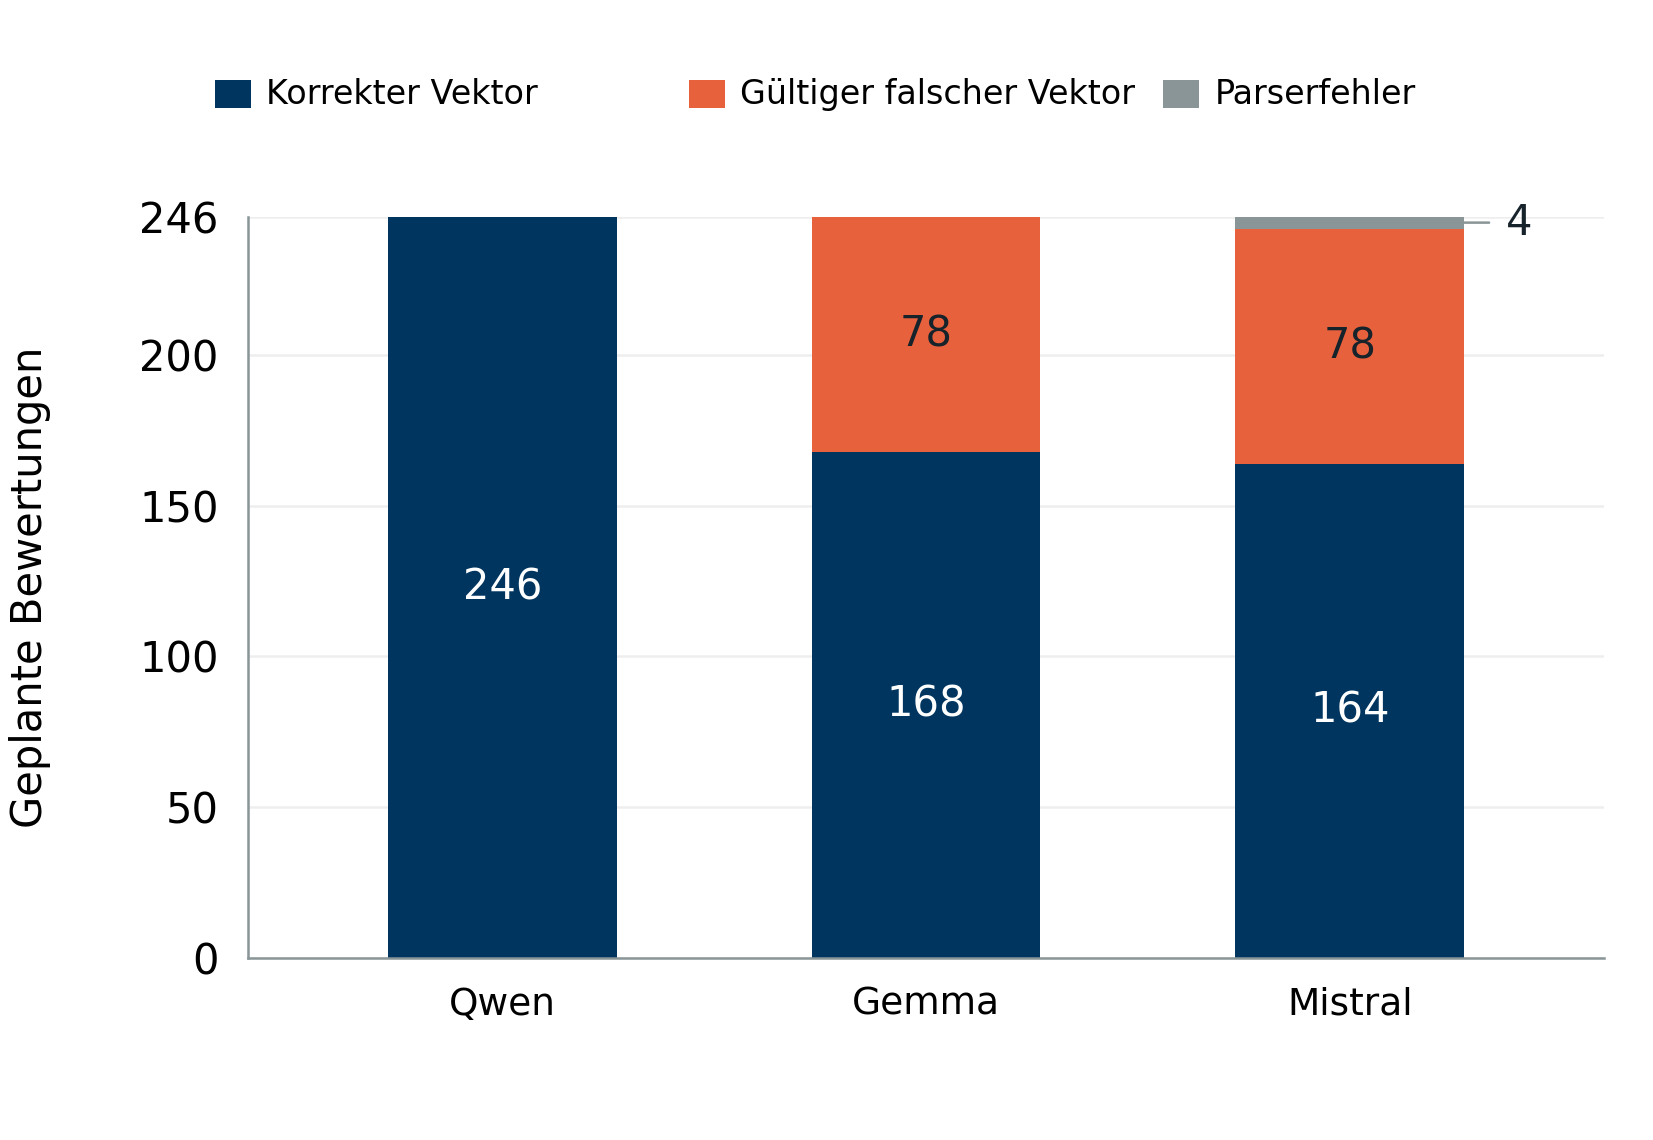

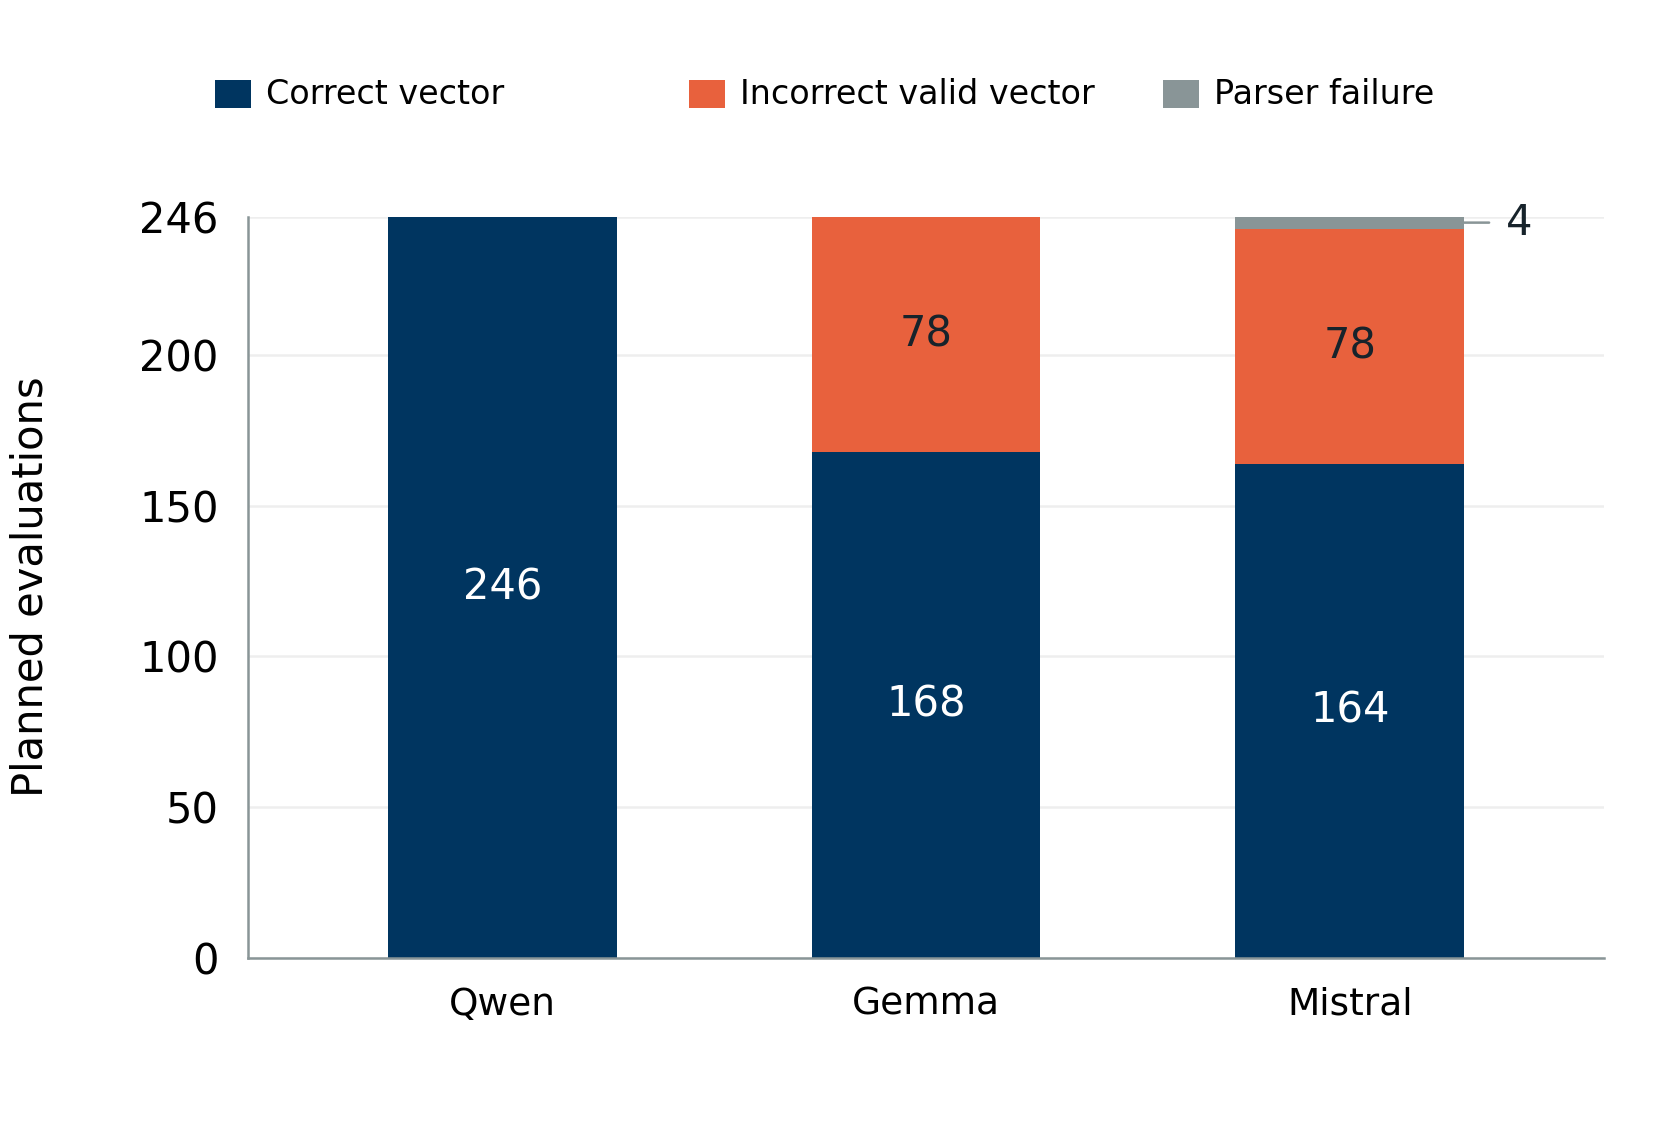

In [5]:
def fraction(numerator, denominator):
    return f"{int(numerator)}/{int(denominator)}"
def percent(rate):
    return f"{100 * float(rate):.1f}".replace(".", ",") + " %"

def appendix_view(frame, index):
    view = frame.set_index(index).T
    for metric in view.index:
        integer = pd.api.types.is_integer_dtype(frame[metric].dtype)
        view.loc[metric] = view.loc[metric].map(
            lambda value: str(int(value)) if integer else f"{float(value):.4f}")
    return view

rq1_view = pd.DataFrame({
    "Modell": rq1["model"].map(MODEL_NAMES),
    "K/N": [fraction(r.exact_correct, r.planned) for r in rq1.itertuples()],
    "K/N (%)": rq1["exact_planned"].map(percent),
    "K/V": [fraction(r.exact_correct, r.valid) for r in rq1.itertuples()],
    "V/N": [fraction(r.valid, r.planned) for r in rq1.itertuples()],
    "Parserfehler": rq1["parser_failure"],
    "Technische Fehler": rq1["technical_failure"]})
display(rq1_view)
check("rq1_segment_regression", rq1[["exact_correct", "valid_incorrect", "parser_failure"]].values.tolist()
      == [[246, 0, 0], [168, 78, 0], [164, 78, 4]])
check("rq1_partition", rq1[["exact_correct", "valid_incorrect", "parser_failure", "technical_failure"]].sum(axis=1).eq(rq1["planned"]).all())
check("no_technical_failure", rq1["technical_failure"].eq(0).all())
export_table(BASE, "tab_v2_rq1", rq1, "Vektorkorrektheit und Ausgabeabdeckung.",
             view=rq1_view, columns="lrrrrrr",
             note="K: vollständig richtige Vektoren; N: geplante Bewertungen; V: gültige Ausgaben. K/N ist die primäre Kennzahl.")
# Complete original RQ1 overview, arranged vertically for the appendix.
full_rq1_view = appendix_view(rq1, "model").rename(columns=MODEL_NAMES).rename_axis("Kennzahl").reset_index()
display(full_rq1_view)
export_table(BASE, "tab_v2_rq1_full", rq1, "Vollständige vorhandene RQ1-Übersicht.",
             view=full_rq1_view, columns="lrrr", long=True)

binary_columns = ["model", "binary_available", "planned", "binary_coverage", "tp", "tn", "fp", "fn",
                  "incoherent", "parser_failure", "technical_failure"]
binary = rq1[binary_columns].copy()
binary_view = pd.DataFrame({
    "Modell": binary["model"].map(MODEL_NAMES),
    "Abdeckung": [fraction(r.binary_available, r.planned) for r in binary.itertuples()],
    "%": binary["binary_coverage"].map(percent),
    "TP": binary["tp"], "TN": binary["tn"], "FP": binary["fp"], "FN": binary["fn"]})
display(binary_view)
export_table(BASE, "tab_v2_binary", binary, "Binäre Abdeckung und Konfusionszählungen.",
             view=binary_view, note="INCONSISTENT ist positiv. TP/TN/FP/FN beziehen sich nur auf verfügbare binäre Urteile. "
             "Mistral: 42 inkohärente NNN-Ausgaben und vier Parserfehler sind ausgeschlossen, keine zusätzlichen FN.")
conditional = rq1[["model", "binary_available", "planned", "binary_coverage", "precision",
                  "recall_conditional", "f1_conditional", "reference_positive", "available_positive",
                  "positive_coverage"]].copy()
conditional_view = pd.DataFrame({
    "Modell": conditional["model"].map(MODEL_NAMES),
    "Abdeckung": [fraction(r.binary_available, r.planned) for r in conditional.itertuples()],
    "Positiv-Abdeckung": [fraction(r.available_positive, r.reference_positive) for r in conditional.itertuples()],
    "Precision": conditional["precision"].map(percent),
    "Recall": conditional["recall_conditional"].map(percent),
    "F1": conditional["f1_conditional"].map(percent)})
display(conditional_view)
export_table(BASE, "tab_v2_binary_conditional", conditional, "Bedingte binäre Kennzahlen.",
             view=conditional_view, note="Precision, Recall und F1 sind auf verfügbare binäre Urteile bedingt. "
             "Die Abdeckung gehört zur Interpretation; fehlende Urteile werden nicht imputiert.")

rq1_data = rq1[["model", "planned", "exact_correct", "valid_incorrect", "parser_failure"]].copy()
rq1_data["model_label"] = rq1_data["model"].map(MODEL_NAMES)
rq1_data["exact_planned"] = rq1["exact_planned"]
fig1, ax1 = column_figure()
stack_columns(ax1, rq1_data, ["exact_correct", "valid_incorrect", "parser_failure"], RQ1_COLORS)
ax1.set(xticks=range(3), xticklabels=rq1_data["model_label"],
        xlim=(-0.6, 2.6), ylim=(0, 246), ylabel="Geplante Bewertungen")
ax1.set_yticks([0, 50, 100, 150, 200, 246])
translations = horizontal_legend(
    fig1, RQ1_COLORS, ["Korrekter Vektor", "Gültiger falscher Vektor", "Parserfehler"],
    ["Correct vector", "Incorrect valid vector", "Parser failure"])
translations.append((ax1.yaxis.label, "Planned evaluations"))
export_language_figures("rq1_vector_outcomes", fig1, rq1_data, translations)
for language in ["de", "en"]:
    display(Image(filename=str(BASE / "figures" / ("rq1_vector_outcomes_" + language + ".png"))))
plt.close(fig1)


## RQ2: Dimensionen, Teilgruppen und vorhandene Paare

**T-DIM ist die vollständige Sicht:** Zustandsübereinstimmung über alle geplanten Bewertungen, einschließlich Referenz-NOT_APPLICABLE, sowie beide Richtungen von Anwendbarkeitsfehlern. Die Grafik ergänzt diese Sicht mit `applicable_correct / applicable_planned`. Die Referenz bestimmt die Anwendbarkeit. Falsch vorhergesagtes NOT_APPLICABLE bleibt ein Fehler; Parserfehler bleiben im geplanten Nenner.

T-GRP enthält zwei getrennte Blöcke (`reference_vector` und `api`); diese Blöcke werden nicht addiert. T-PAIR übernimmt die sechs vorhandenen Vergleichstypen und 39 Verknüpfungen im Main. Kontrollen werden als Kontrollen bezeichnet. Ausgeschlossene Originale werden nicht nachträglich bewertet.

Caption: **Korrektheit bei referenzseitig anwendbaren Prüfungen.**

,Modell,Kat.,Zustand K/N,%,Falsch anwendbar,Falsch N/A
0,Qwen,C1,246/246,"100,0 %",0,0
1,Qwen,C2,246/246,"100,0 %",0,0
2,Qwen,C3,246/246,"100,0 %",0,0
3,Gemma,C1,204/246,"82,9 %",0,0
4,Gemma,C2,204/246,"82,9 %",42,0
5,Gemma,C3,168/246,"68,3 %",42,0
6,Mistral,C1,200/246,"81,3 %",0,42
7,Mistral,C2,242/246,"98,4 %",0,0
8,Mistral,C3,206/246,"83,7 %",0,0


,Block,Gruppe,Fälle,Qwen,Gemma,Mistral
0,Referenz,PPP,29,87/87,81/87,80/87
1,Referenz,PPF,10,30/30,0/30,1/30
2,Referenz,PFN,29,87/87,87/87,83/87
3,Referenz,FNN,14,42/42,0/42,0/42
4,API,EDX,52,156/156,84/156,84/156
5,API,Resistance,30,90/90,84/90,80/90


,Vergleich,Paare,Qwen,Gemma,Mistral
0,EDX: C1-Regression,8,24/24,0/24,0/24
1,EDX: C2-Regression,8,24/24,0/24,1/24
2,EDX: konformer Zustand,8,24/24,0/24,1/24
3,EDX: Formatkontrolle,1,3/3,0/3,0/3
4,Resistance: Request-Kontrolle,1,3/3,0/3,3/3
5,Resistance: C2-Regression,13,39/39,39/39,33/39


,model,category,applicable_correct,applicable_planned,accuracy_percent
0,qwen3.6:27b,C1,246,246,100.000000
1,qwen3.6:27b,C2,204,204,100.000000
2,qwen3.6:27b,C3,117,117,100.000000
3,gemma3:27b,C1,204,246,82.926829
4,gemma3:27b,C2,204,204,100.000000
5,gemma3:27b,C3,81,117,69.230769
6,mistral-small3.2:24b,C1,200,246,81.300813
7,mistral-small3.2:24b,C2,200,204,98.039216
8,mistral-small3.2:24b,C3,81,117,69.230769


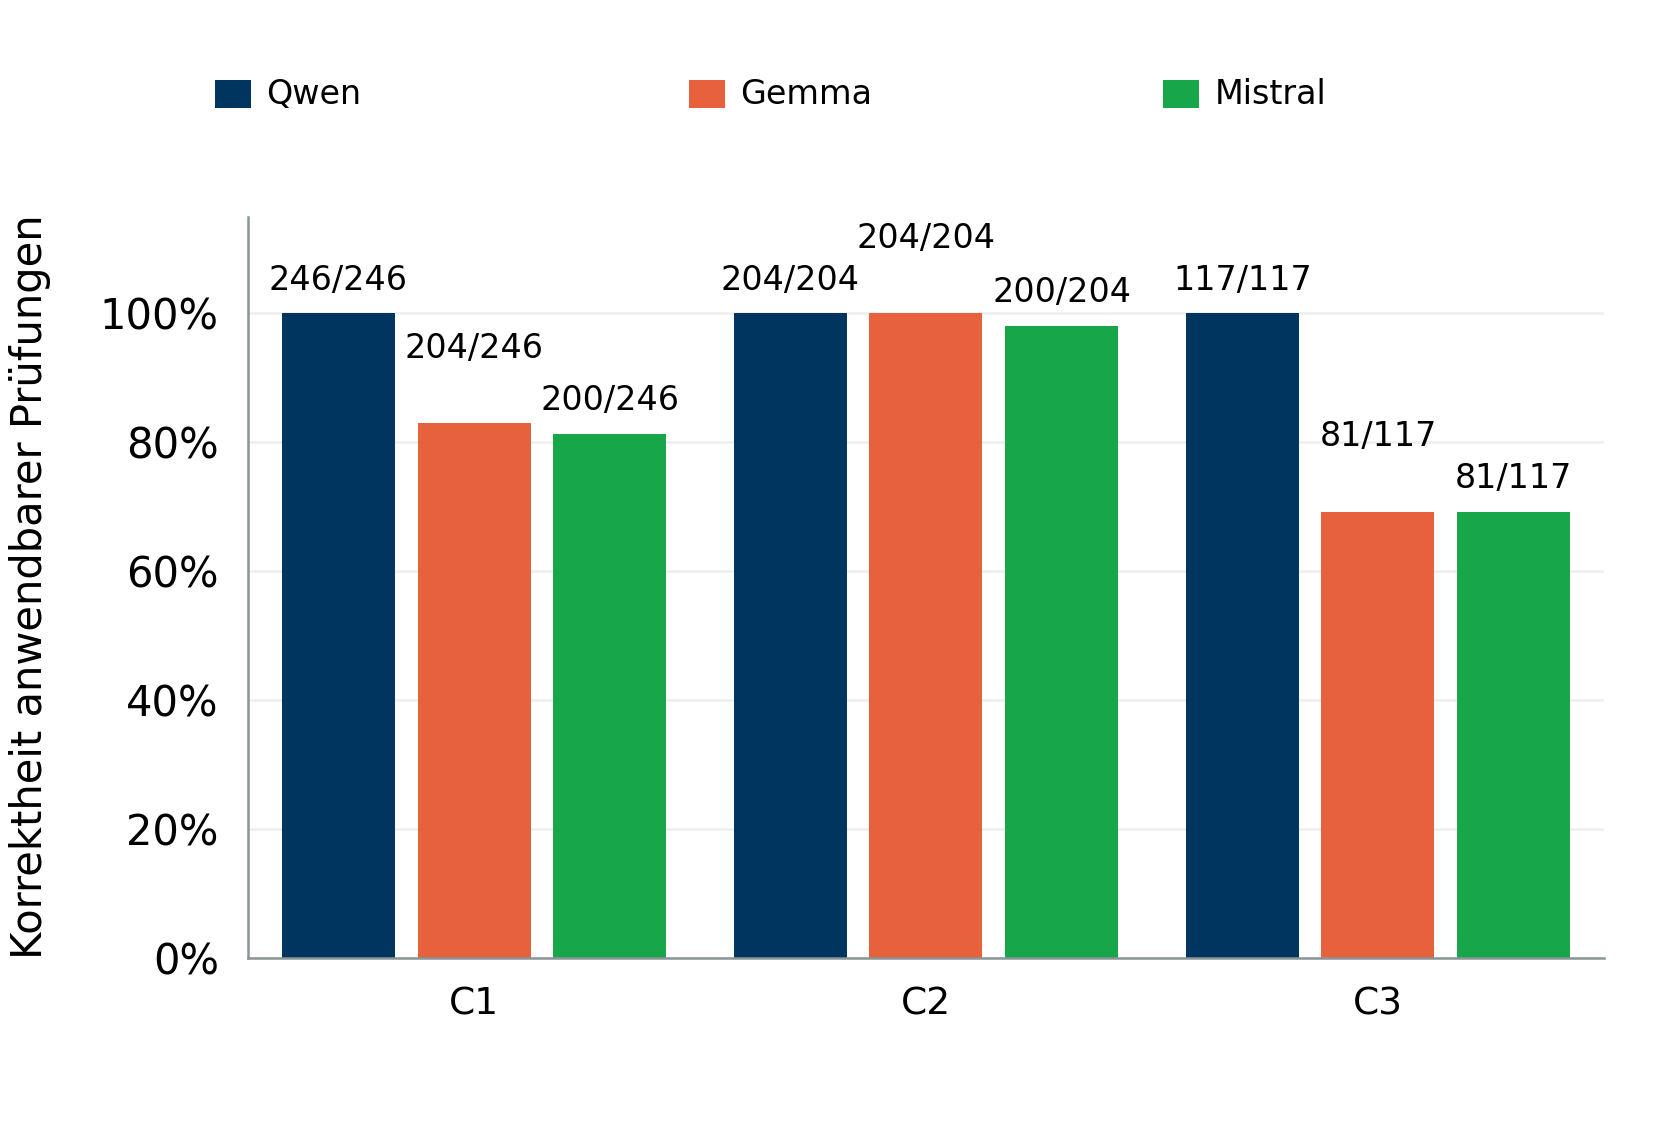

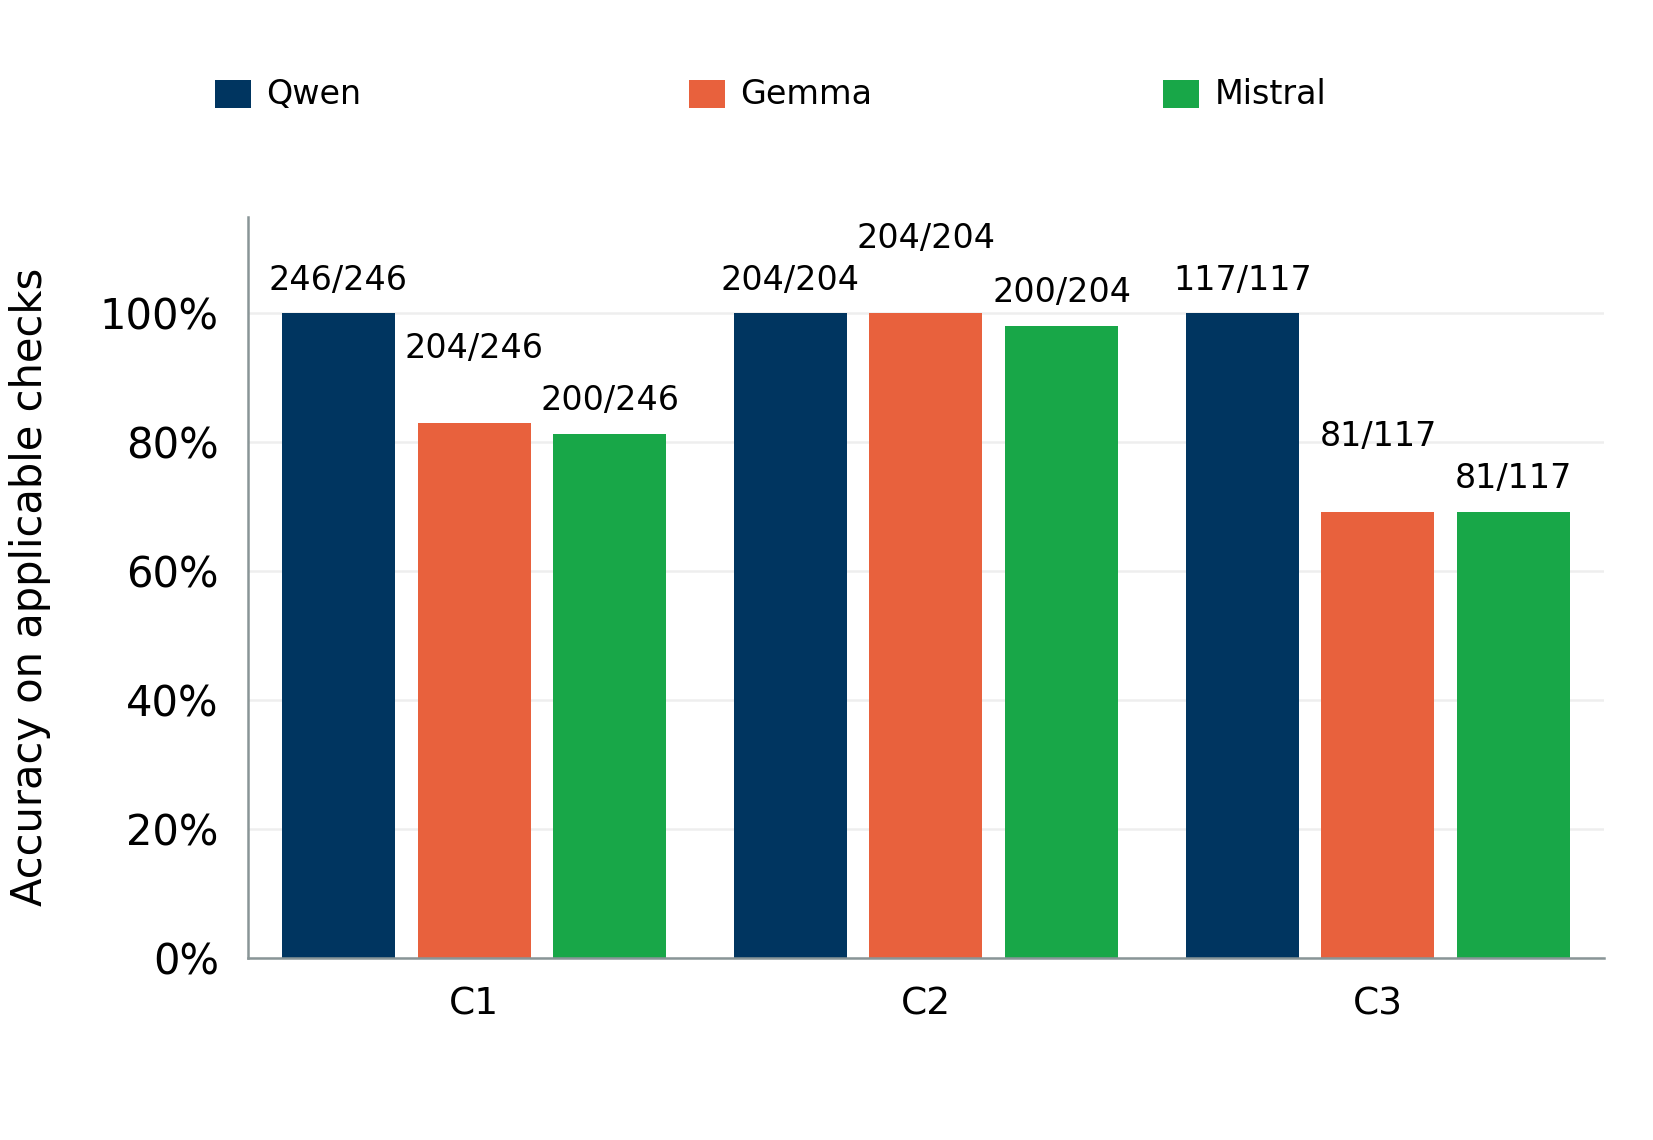

In [6]:
for _, row in categories.iterrows():
    group = runs.loc[runs["model"].eq(row["model"])]
    cat = row["category"].lower()
    reference, prediction = group["reference_" + cat], group["predicted_" + cat]
    valid = group["output_valid"]
    applicable = reference.ne("NOT_APPLICABLE")
    controls = {
        "planned": len(group), "valid": int(valid.sum()),
        "correct": int((valid & reference.eq(prediction)).sum()),
        "applicable_planned": int(applicable.sum()),
        "applicable_valid": int((applicable & valid).sum()),
        "applicable_correct": int((applicable & valid & reference.eq(prediction)).sum()),
        "category_fp": int((valid & reference.eq("PASS") & prediction.eq("FAIL")).sum()),
        "category_fn": int((valid & reference.eq("FAIL") & prediction.eq("PASS")).sum()),
        "false_applicable": int((valid & reference.eq("NOT_APPLICABLE") & prediction.ne("NOT_APPLICABLE")).sum()),
        "false_not_applicable": int((valid & reference.ne("NOT_APPLICABLE") & prediction.eq("NOT_APPLICABLE")).sum())}
    for field, value in controls.items():
        check("category/" + str(row["model"]) + "/" + row["category"] + "/" + field, row[field] == value)
    check("category_partition/" + str(row["model"]) + "/" + row["category"],
          row["correct"] + row["category_fp"] + row["category_fn"] +
          row["false_applicable"] + row["false_not_applicable"] == row["valid"])
check("category_denominators", categories["applicable_planned"].tolist() == [246, 204, 117] * 3)
check("category_numerators", categories["applicable_correct"].tolist() ==
      [246, 204, 117, 204, 204, 81, 200, 200, 81])
dimension_view = pd.DataFrame({
    "Modell": categories["model"].map(MODEL_NAMES), "Kat.": categories["category"],
    "Zustand K/N": [fraction(r.correct, r.planned) for r in categories.itertuples()],
    "%": categories["correctness_planned"].map(percent),
    "Falsch anwendbar": categories["false_applicable"],
    "Falsch N/A": categories["false_not_applicable"]})
display(dimension_view)
export_table(BASE, "tab_v2_dimensions", categories, "Übereinstimmung der vollständigen Kategoriezustände.",
             view=dimension_view, columns="llrrrr",
             note="Zustand K/N umfasst PASS, FAIL und Referenz-NOT_APPLICABLE. N enthält Parserfehler. "
             "Falsch anwendbar: Referenz N/A, gültige Prediction PASS/FAIL. Falsch N/A: Referenz anwendbar, Prediction N/A.")

selected_groups = subgroups.loc[subgroups["grouping"].isin(["reference_vector", "api"])].copy()
group_rows = []
for block, group_order in [("reference_vector", ["PPP", "PPF", "PFN", "FNN"]),
                            ("api", ["EDX", "Resistance"])]:
    for group in group_order:
        source = selected_groups.loc[selected_groups["grouping"].eq(block) & selected_groups["group"].eq(group)].set_index("model")
        check("group_case_counts/" + block + "/" + group, source["cases"].nunique() == 1)
        row = {"Block": "Referenz" if block == "reference_vector" else "API", "Gruppe": group,
               "Fälle": int(source["cases"].iloc[0])}
        for model in MODEL_ORDER:
            row[MODEL_NAMES[model]] = fraction(source.loc[model, "exact_correct"], source.loc[model, "planned"])
        group_rows.append(row)
group_view = pd.DataFrame(group_rows)
display(group_view)
export_table(BASE, "tab_v2_subgroups", selected_groups, "Vektorkorrektheit nach Referenzgruppe und API.",
             view=group_view, columns="llrrrr", block_column="Block",
             note="Modellspalten: vollständig richtige Vektoren / geplante Bewertungen. "
             "Referenz- und API-Blöcke sind separate Gruppierungen desselben Datensatzes.")

check("pair_summary_types", pair_summary["group"].nunique() == 6)
check("pair_membership_count", len(pairs[["original", "variant"]].drop_duplicates()) == 39 and len(pairs) == 39 * 9)
check("pairs_in_main", set(pairs["original"]) <= set(cases["case_id"]) and set(pairs["variant"]) <= set(cases["case_id"]))
for _, row in pair_summary.iterrows():
    subset = pairs.loc[pairs["model"].eq(row["model"]) & pairs["group"].eq(row["group"])]
    check("pair_summary/" + str(row["group"]) + "/" + str(row["model"]),
          len(subset) == row["paired_repetitions"] == row["pairs"] * 3
          and subset["both_valid"].sum() == row["both_valid"]
          and subset["both_correct"].sum() == row["both_correct"]
          and subset["identical_predictions"].sum() == row["identical_predictions"])
pair_labels = {"EDX:c1_regressive": "EDX: C1-Regression", "EDX:c2_regressive": "EDX: C2-Regression",
               "EDX:conforming": "EDX: konformer Zustand", "EDX:formatting_control": "EDX: Formatkontrolle",
               "Resistance:REQUEST_VALIDATION_CONTROL": "Resistance: Request-Kontrolle",
               "Resistance:c2_regressive": "Resistance: C2-Regression"}
check("pair_type_labels", set(pair_labels) == set(pair_summary["group"]))
pair_rows = []
for group in sorted(pair_labels):
    source = pair_summary.loc[pair_summary["group"].eq(group)].set_index("model")
    check("pair_counts_per_model/" + group, source["pairs"].nunique() == 1)
    row = {"Vergleich": pair_labels[group], "Paare": int(source["pairs"].iloc[0])}
    for model in MODEL_ORDER:
        row[MODEL_NAMES[model]] = fraction(source.loc[model, "both_correct"], source.loc[model, "paired_repetitions"])
    pair_rows.append(row)
pair_view = pd.DataFrame(pair_rows)
check("pair_total_39", pair_view["Paare"].sum() == 39)
display(pair_view)
export_table(BASE, "tab_v2_pairs", pair_summary, "Vorhandene Vergleiche innerhalb des Main-Datensatzes.",
             view=pair_view, columns="lrrrr",
             note="Modellspalten: beide Vektoren korrekt / geplante Paar-Wiederholungen. "
             "39 Verknüpfungen; Kontrollen sind keine automatisch inkonsistenten Fälle.")

rq2_data = categories[["model", "category", "applicable_correct", "applicable_planned"]].copy()
rq2_data["accuracy_percent"] = 100 * rq2_data["applicable_correct"] / rq2_data["applicable_planned"]
check("category_plot_ratio", (rq2_data["accuracy_percent"] / 100 -
      categories["applicable_correctness_planned"]).abs().lt(1e-12).all())
display(rq2_data)
fig2, ax2 = column_figure()
for index, model in enumerate(MODEL_ORDER):
    rows = rq2_data.loc[rq2_data["model"].eq(model)].set_index("category").loc[CATEGORIES]
    positions = [x * 1.2 + (index - 1) * 0.36 for x in range(3)]
    bars = ax2.bar(positions, rows["accuracy_percent"], width=0.30,
                  color=RQ2_COLORS[index], edgecolor="none", linewidth=0)
    for bar, row in zip(bars, rows.itertuples()):
        ax2.annotate(fraction(row.applicable_correct, row.applicable_planned),
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 14 if index == 1 else 4), textcoords="offset points",
                     ha="center", va="bottom", rotation=0, fontsize=8)
ax2.set(ylim=(0, 115), xlim=(-0.6, 3.0), xticks=[0, 1.2, 2.4],
        xticklabels=["C1", "C2", "C3"], ylabel="Korrektheit anwendbarer Prüfungen")
ax2.set_yticks([0, 20, 40, 60, 80, 100])
ax2.yaxis.set_major_formatter(PercentFormatter(xmax=100))
translations = horizontal_legend(
    fig2, RQ2_COLORS, ["Qwen", "Gemma", "Mistral"], ["Qwen", "Gemma", "Mistral"])
translations.append((ax2.yaxis.label, "Accuracy on applicable checks"))
export_language_figures("rq2_applicable_category_accuracy", fig2, rq2_data, translations)
for language in ["de", "en"]:
    display(Image(filename=str(BASE / "figures" / ("rq2_applicable_category_accuracy_" + language + ".png"))))
plt.close(fig2)


## RQ3: Stabilität und Korrektheit je Fall

Jedes Segment zählt Fall-Modell-Dreiergruppen. Drei gleiche gültige NNN-Vektoren sind stabil falsch. Eine Gruppe mit fehlender gültiger Ausgabe bleibt unvollständig, auch wenn ihre übrigen Vektoren identisch sind. Die bedingte Identitätsrate betrachtet ausschließlich vollständige gültige Dreiergruppen und steht getrennt in der Tabelle. Es werden keine Majority-Vote-Urteile ergänzt.

Caption: **Stabilität und Korrektheit der wiederholten Entscheidungen.**

,Modell,3/3 korrekt,Stabil falsch,Variabel,Unvollständig,Identisch/Vollst.
0,Qwen,82,0,0,0,82/82
1,Gemma,56,26,0,0,82/82
2,Mistral,53,25,2,2,78/80


/var/folders/4q/y2pm84qx3gq84x1m9y0dpr0w0000gn/T/ipykernel_8803/4149583099.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '82' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  view.loc[metric] = view.loc[metric].map(
/var/folders/4q/y2pm84qx3gq84x1m9y0dpr0w0000gn/T/ipykernel_8803/4149583099.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '82' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  view.loc[metric] = view.loc[metric].map(
/var/folders/4q/y2pm84qx3gq84x1m9y0dpr0w0000gn/T/ipykernel_8803/4149583099.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '82' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  

model,Kennzahl,Qwen,Gemma,Mistral
0,cases,82,82,82
1,complete_valid_triples,82,82,80
2,triple_coverage,1.0000,1.0000,0.9756
3,identical_triples,82,82,78
4,identical_given_complete,1.0000,1.0000,0.9750
5,all_three_correct,82,56,53
6,all_three_correct_rate,1.0000,0.6829,0.6463
7,stable_wrong,0,26,25
8,variable,0,0,2
9,two_plus_one,0,0,2


,model,repetition,seed,planned,valid,parser_failure,technical_failure,valid_incorrect,exact_correct,exact_planned,...,fp,fn,precision,recall_conditional,f1_conditional,reference_positive,available_positive,positive_coverage,tp_over_all_reference_positive,runs_with_applicability_error
0,qwen3.6:27b,1,101,82,82,0,0,0,82,1.000000,...,0,0,1.000000,1.000000,1.000000,53,53,1.000000,1.000000,0
1,qwen3.6:27b,2,202,82,82,0,0,0,82,1.000000,...,0,0,1.000000,1.000000,1.000000,53,53,1.000000,1.000000,0
2,qwen3.6:27b,3,303,82,82,0,0,0,82,1.000000,...,0,0,1.000000,1.000000,1.000000,53,53,1.000000,1.000000,0
3,gemma3:27b,1,101,82,82,0,0,26,56,0.682927,...,2,24,0.935484,0.547170,0.690476,53,53,1.000000,0.547170,14
4,gemma3:27b,2,202,82,82,0,0,26,56,0.682927,...,2,24,0.935484,0.547170,0.690476,53,53,1.000000,0.547170,14
5,gemma3:27b,3,303,82,82,0,0,26,56,0.682927,...,2,24,0.935484,0.547170,0.690476,53,53,1.000000,0.547170,14
6,mistral-small3.2:24b,1,101,82,80,2,0,26,54,0.658537,...,2,10,0.931034,0.729730,0.818182,53,37,0.698113,0.509434,14
7,mistral-small3.2:24b,2,202,82,82,0,0,25,57,0.695122,...,2,9,0.937500,0.769231,0.845070,53,39,0.735849,0.566038,14
8,mistral-small3.2:24b,3,303,82,80,2,0,27,53,0.646341,...,3,10,0.900000,0.729730,0.805970,53,37,0.698113,0.509434,14


/var/folders/4q/y2pm84qx3gq84x1m9y0dpr0w0000gn/T/ipykernel_8803/4149583099.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '101' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  view.loc[metric] = view.loc[metric].map(
/var/folders/4q/y2pm84qx3gq84x1m9y0dpr0w0000gn/T/ipykernel_8803/4149583099.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '202' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  view.loc[metric] = view.loc[metric].map(
/var/folders/4q/y2pm84qx3gq84x1m9y0dpr0w0000gn/T/ipykernel_8803/4149583099.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '303' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.

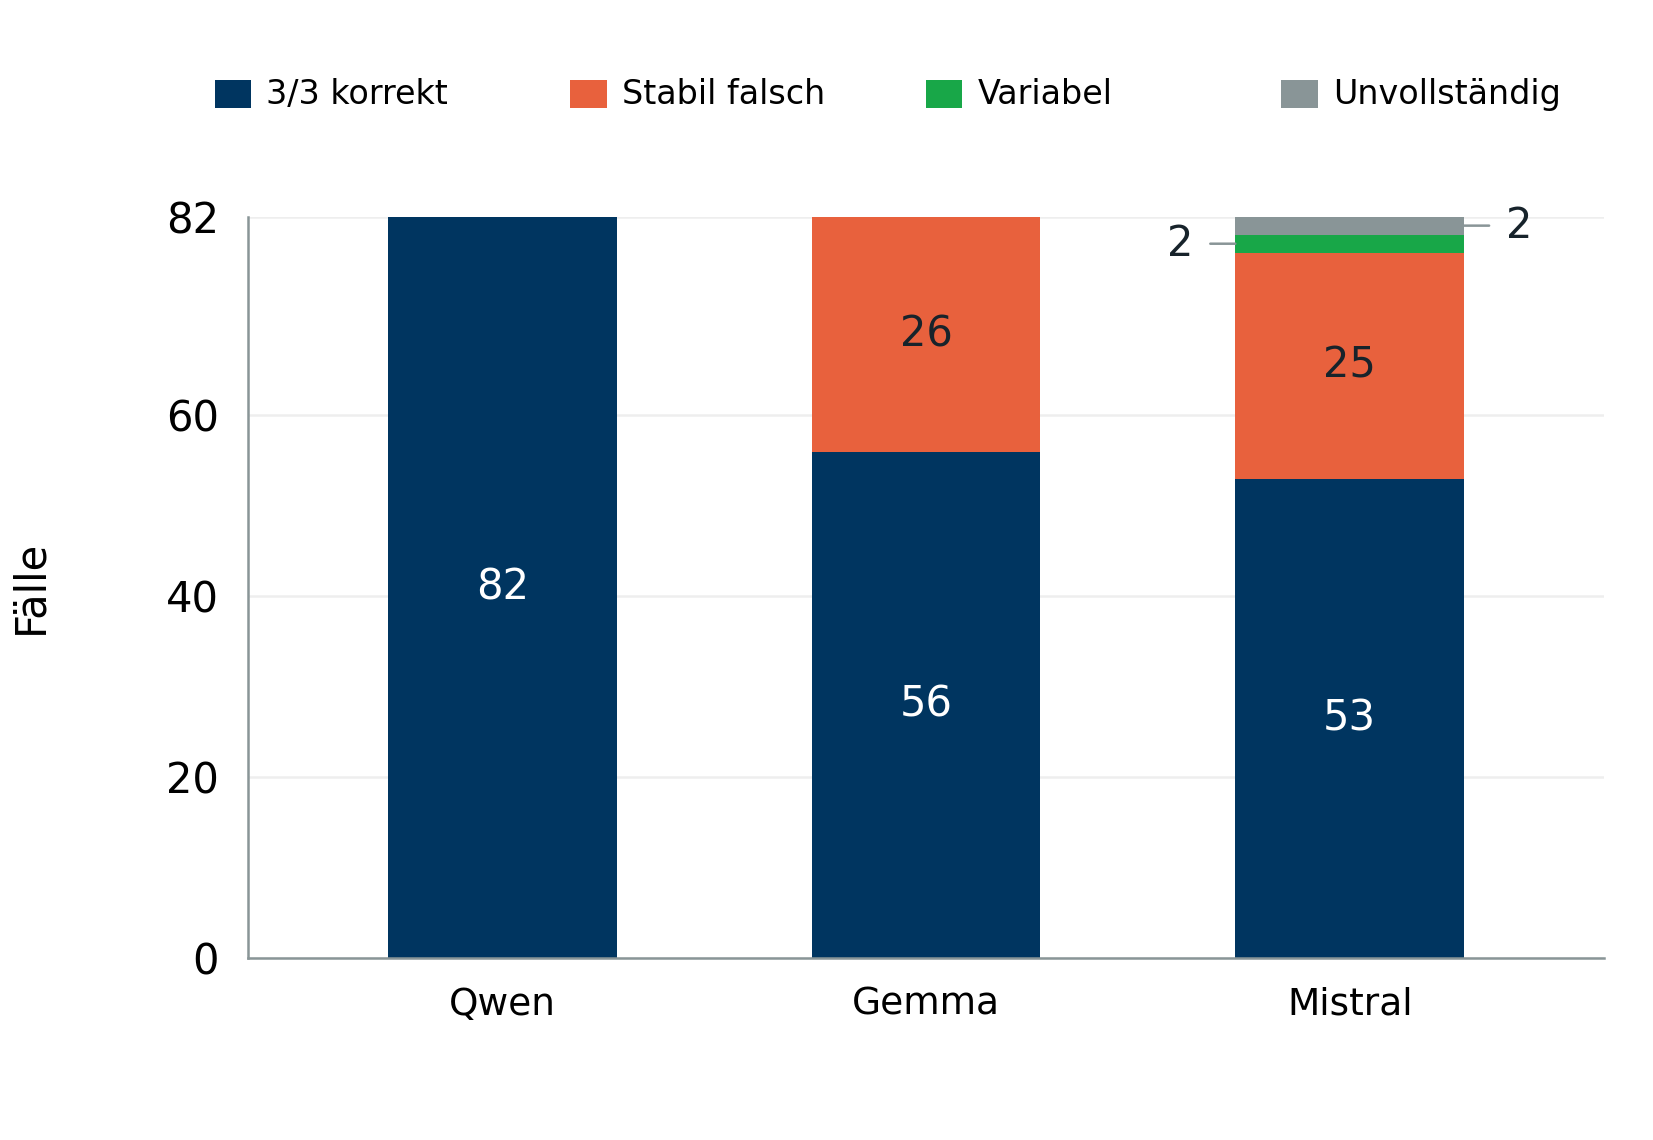

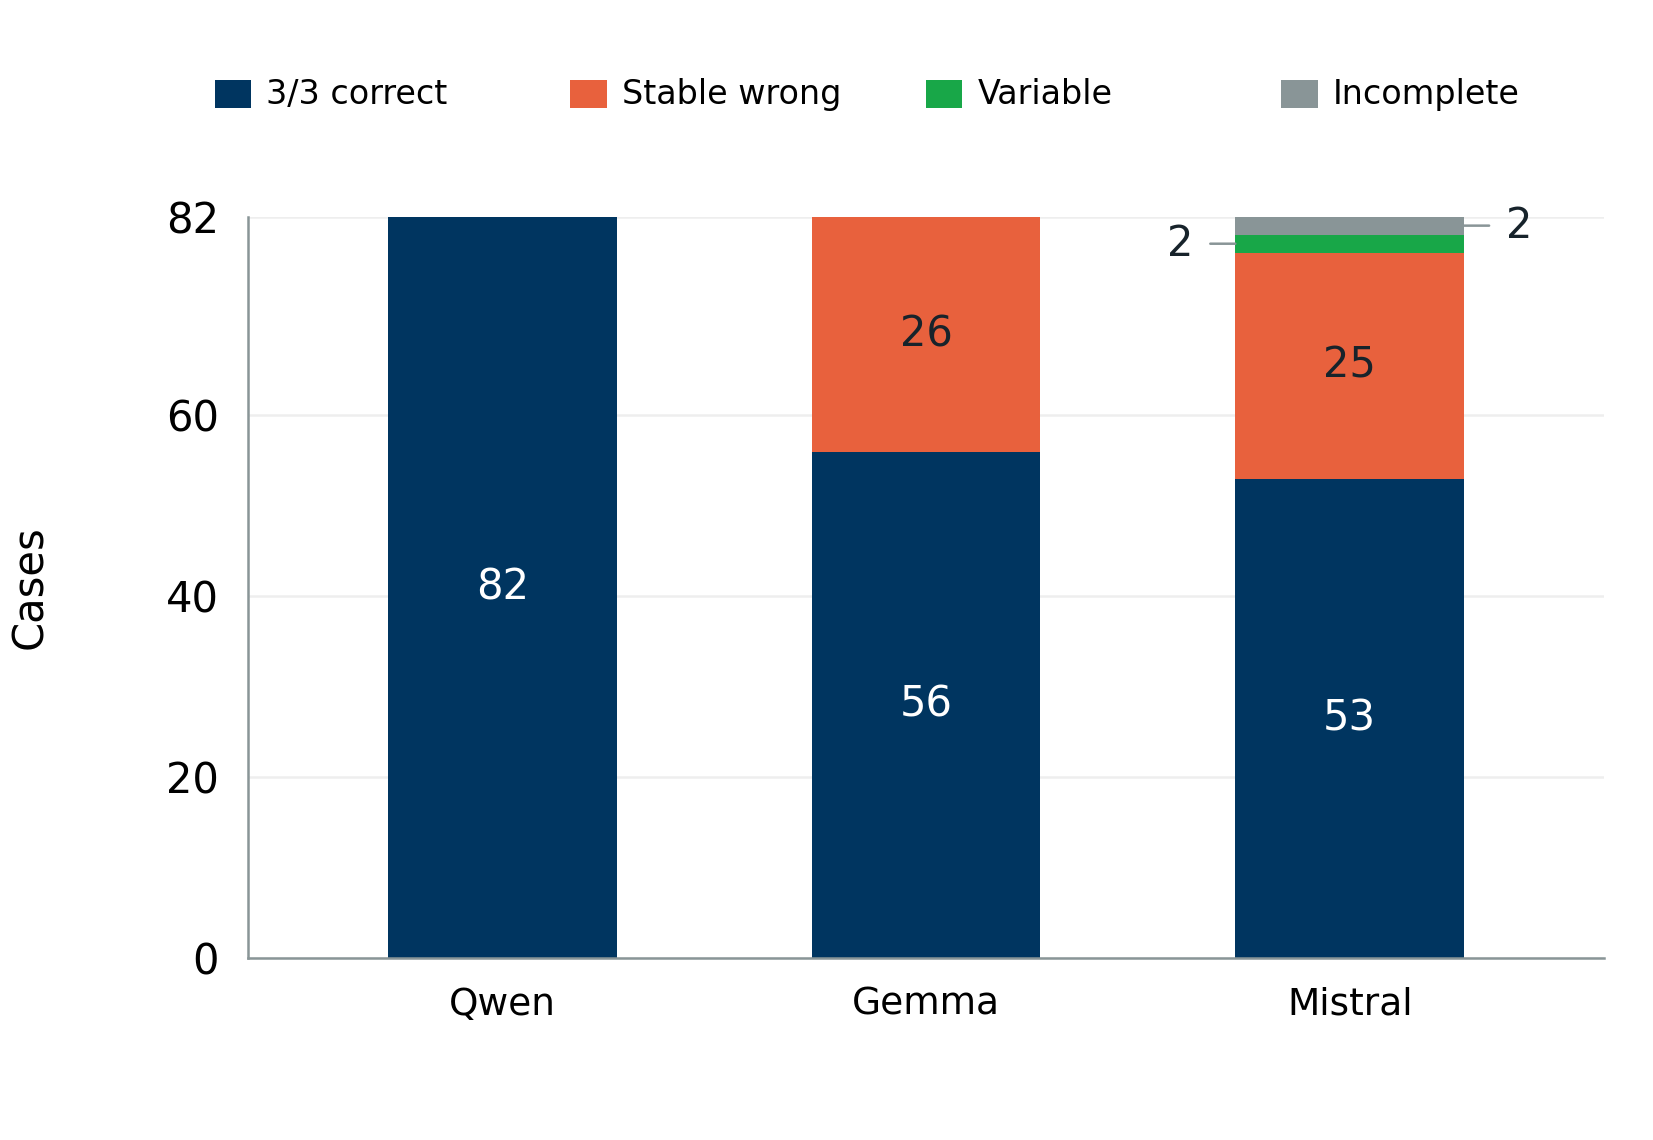

In [7]:
check("triple_cardinality", len(triples) == 246 and not triples.duplicated(["case_id", "model"]).any())
lookup = runs.set_index(["case_id", "model", "repetition"])
for row in triples.itertuples():
    observed = [lookup.loc[(row.case_id, row.model, rep), "predicted_vector"] for rep in [1, 2, 3]]
    source_vectors = [row.r1, row.r2, row.r3]
    check("triple_vectors/" + row.case_id + "/" + str(row.model),
          source_vectors == [value if value else "PARSER_FAILURE" for value in observed])
    full = all(observed)
    distinct = len({value for value in observed if value})
    correct = sum(value == row.reference_vector for value in observed)
    check("triple_fields/" + row.case_id + "/" + str(row.model),
          row.valid_repetitions == sum(bool(value) for value in observed)
          and row.correct_repetitions == correct and row.distinct_valid_vectors == distinct
          and row.full_valid_triple == full and row.all_three_correct == (correct == 3))
    expected_kind = ("INCOMPLETE_OUTPUT" if not full else "STABLE_CORRECT" if correct == 3
                     else "STABLE_WRONG" if distinct == 1 else "VARIABLE")
    check("triple_type/" + row.case_id + "/" + str(row.model), row.result_type == expected_kind)
for _, row in stability.iterrows():
    subset = triples.loc[triples["model"].eq(row["model"])]
    counts = subset["result_type"].value_counts()
    controls = {"all_three_correct": counts.get("STABLE_CORRECT", 0),
                "stable_wrong": counts.get("STABLE_WRONG", 0), "variable": counts.get("VARIABLE", 0),
                "incomplete": counts.get("INCOMPLETE_OUTPUT", 0)}
    for field, value in controls.items():
        check("stability/" + str(row["model"]) + "/" + field, row[field] == value)
    check("stability_complete/" + str(row["model"]),
          row["complete_valid_triples"] == subset["full_valid_triple"].sum()
          and row["identical_triples"] == subset["stable_vector"].sum()
          and sum(controls.values()) == row["cases"])
check("stability_segment_regression", stability[["all_three_correct", "stable_wrong", "variable", "incomplete"]].values.tolist()
      == [[82, 0, 0, 0], [56, 26, 0, 0], [53, 25, 2, 2]])
check("conditional_identity_regression", stability[["identical_triples", "complete_valid_triples"]].values.tolist()
      == [[82, 82], [82, 82], [78, 80]])
check("nnn_stable_wrong", triples.loc[triples[["r1", "r2", "r3"]].eq("NNN").all(axis=1), "result_type"].eq("STABLE_WRONG").all())
check("incomplete_with_identical_remainder", triples.loc[~triples["full_valid_triple"] & triples["distinct_valid_vectors"].eq(1),
                                                          "result_type"].eq("INCOMPLETE_OUTPUT").all())
rq3_view = pd.DataFrame({
    "Modell": stability["model"].map(MODEL_NAMES), "3/3 korrekt": stability["all_three_correct"],
    "Stabil falsch": stability["stable_wrong"], "Variabel": stability["variable"],
    "Unvollständig": stability["incomplete"],
    "Identisch/Vollst.": [fraction(r.identical_triples, r.complete_valid_triples) for r in stability.itertuples()]})
display(rq3_view)
export_table(BASE, "tab_v2_rq3", stability, "Stabilität und Korrektheit der Dreiergruppen.",
             view=rq3_view, note="Die Segmente beziehen sich jeweils auf 82 Fälle. "
             "Die Identitätsrate ist auf vollständige gültige Dreiergruppen bedingt.")
full_rq3_view = appendix_view(stability, "model").rename(columns=MODEL_NAMES).rename_axis("Kennzahl").reset_index()
display(full_rq3_view)
export_table(BASE, "tab_v2_rq3_full", stability, "Vollständige vorhandene RQ3-Stabilitätsübersicht.",
             view=full_rq3_view, columns="lrrr", long=True)
display(repetitions)
# Preserve the complete per-repetition source table digitally; compact appendix views per model.
repetitions.to_csv(BASE / "tables/rq3_repetitions.csv", index=False, lineterminator="\n")
for model in MODEL_ORDER:
    view = appendix_view(repetitions.loc[repetitions["model"].eq(model)].drop(columns="model"), "repetition")
    view.columns = [f"Wiederholung {int(rep)}" for rep in view.columns]
    view = view.rename_axis("Kennzahl").reset_index()
    export_table(BASE, "tab_v2_repetitions_" + MODEL_NAMES[model].lower(),
                 repetitions.loc[repetitions["model"].eq(model)],
                 MODEL_NAMES[model] + ": vollständige Übersicht der Wiederholungen.",
                 view=view, columns="lrrr", long=True)

rq3_data = triples.groupby("model", observed=True)["result_type"].value_counts().unstack(fill_value=0).reindex(MODEL_ORDER)
rq3_data = rq3_data.rename(columns={"STABLE_CORRECT": "all_three_correct", "STABLE_WRONG": "stable_wrong",
                                    "VARIABLE": "variable", "INCOMPLETE_OUTPUT": "incomplete"})
rq3_data = rq3_data.reindex(columns=["all_three_correct", "stable_wrong", "variable", "incomplete"], fill_value=0)
rq3_data["cases"] = rq3_data.sum(axis=1)
rq3_data = rq3_data.reset_index().rename_axis(None, axis=1)
rq3_data["model_label"] = rq3_data["model"].map(MODEL_NAMES)
fig3, ax3 = column_figure()
stack_columns(ax3, rq3_data, ["all_three_correct", "stable_wrong", "variable", "incomplete"], RQ3_COLORS)
ax3.set(xticks=range(3), xticklabels=rq3_data["model_label"],
        xlim=(-0.6, 2.6), ylim=(0, 82), ylabel="Fälle")
ax3.set_yticks([0, 20, 40, 60, 82])
translations = horizontal_legend(
    fig3, RQ3_COLORS, ["3/3 korrekt", "Stabil falsch", "Variabel", "Unvollständig"],
    ["3/3 correct", "Stable wrong", "Variable", "Incomplete"])
translations.append((ax3.yaxis.label, "Cases"))
export_language_figures("rq3_stability_correctness", fig3, rq3_data, translations)
for language in ["de", "en"]:
    display(Image(filename=str(BASE / "figures" / ("rq3_stability_correctness_" + language + ".png"))))
plt.close(fig3)


## Exporte und Abschlusskontrollen

Alle drei Zeichendatensätze werden als CSV gespeichert. Jede Abbildung erzeugt je eine deutsche und englische PDF-/PNG-Variante aus derselben Figure und demselben berechneten Datenobjekt. Die bisherigen Exporte ohne Sprachsuffix bleiben unverändert erhalten. Der Sprachwechsel ändert ausschließlich Textinhalte; die Gleichheit der Diagrammgeometrie und Formatierung wird separat in `provenance/bilingual_geometry.json` geprüft. PDF-Erstellungs- und Änderungszeitpunkte werden entfernt. Die folgende Zelle vergleicht bei wiederholter Ausführung mit frischem Kernel die Zahlen, Zeichendaten und Grafik-Hashes für dieselben Quellzellen, Hilfsfunktionen und Paketversionen. Bytegleichheit wird nur für diese Umgebung geprüft.

Die tatsächliche Sichtprüfung der PNG-Dateien und der gerenderten PDFs wird nach der Ausführung separat in `provenance/bilingual_verification.json` dokumentiert; `provenance/visual_review.json` bleibt als historischer Nachweis erhalten. Ein fehlerfreier Notebook-Lauf allein gilt nicht als Sichtprüfung. Die abschließende Notebook-Datei wird nach dem Speichern im Liefermanifest gehasht.

In [8]:
from analysis_support import artifact_hashes
original_stems = {"rq1_vector_outcomes", "rq2_applicable_category_accuracy", "rq3_stability_correctness"}
language_stems = {name + "_" + language for name in original_stems for language in ["de", "en"]}
check("exactly_three_pdfs", len([p for p in (BASE / "figures").glob("*.pdf") if p.stem in original_stems]) == 3)
check("exactly_three_pngs", len([p for p in (BASE / "figures").glob("*.png") if p.stem in original_stems]) == 3)
for extension in ["pdf", "png"]:
    assert {p.stem for p in (BASE / "figures").glob("*." + extension)} == original_stems | language_stems
assert set(language_graphics) == original_stems
write_json(BASE / "provenance/bilingual_geometry.json", language_graphics)
check("exactly_three_drawing_csvs", len(list((BASE / "provenance/figure_data").glob("*.csv"))) == 3)
check("figure_names", {p.stem for p in (BASE / "figures").glob("*.pdf") if p.stem in original_stems} ==
      {"rq1_vector_outcomes", "rq2_applicable_category_accuracy", "rq3_stability_correctness"})
for filename, expected in EXPECTED.items():
    check("source_preserved/" + filename, sha((INPUTS / filename).read_bytes()) == expected)
for name, expected in [("rq1_vector_outcomes", rq1_data),
                       ("rq2_applicable_category_accuracy", rq2_data),
                       ("rq3_stability_correctness", rq3_data)]:
    observed = pd.read_csv(BASE / "provenance/figure_data" / (name + ".csv"), keep_default_na=False)
    pd.testing.assert_frame_equal(observed, expected, check_dtype=False, check_categorical=False, atol=1e-12, rtol=0)
    check("drawing_roundtrip/" + name, True)

notebook_document = json.loads(NOTEBOOK.read_text())
source_cells = [{"cell_type": c["cell_type"], "source": c["source"]}
                for c in notebook_document["cells"]]
notebook_source_hash = sha(json.dumps(source_cells, ensure_ascii=False, sort_keys=True).encode())
helper_hash = sha((BASE / "analysis_support.py").read_bytes())
fingerprint = sha(json.dumps({"cells": notebook_source_hash, "helper": helper_hash,
                              "environment": ENVIRONMENT, "inputs": source_hashes},
                             sort_keys=True).encode())
current_artifacts = artifact_hashes(BASE)
receipt_path = BASE / "provenance/reproduction.json"
previous = json.loads(receipt_path.read_text()) if receipt_path.exists() else None
same_setup = previous is not None and previous["fingerprint"] == fingerprint
if same_setup:
    check("repeat_artifact_hashes", previous["artifact_hashes"] == current_artifacts)
    successful_passes = previous["successful_passes"] + 1
else:
    successful_passes = 1
write_json(receipt_path, {"fingerprint": fingerprint, "successful_passes": successful_passes,
                         "artifact_hashes": current_artifacts,
                         "byte_identical_same_environment": True if same_setup else None,
                         "fresh_kernel_requirement": "Each full execution starts a new isolated Jupyter kernel; see execution_log.json.",
                         "scope": "Figures, table exports and drawing data only; no cross-platform guarantee."})
write_json(BASE / "provenance/checks.json", {
    "status": "PASS", "checks": checks, "check_count": len(checks),
    "control_method": "Existing hash-bound derive/metrics definitions and direct source-table count comparisons.",
    "bound_counts": {"runs": len(runs), "cases": len(cases), "valid": int(runs["output_valid"].sum()),
                     "parser_failure": int(failure.sum()), "technical_failure": 0},
    "api_cases": cases["api"].value_counts().to_dict(),
    "reference_cases": cases["reference_vector"].value_counts().to_dict(),
    "excluded_binary": {"mistral_nnn": int(nnn.sum()), "parser_failure": int(failure.sum())},
    "execution": "Headless notebook execution in an isolated Jupyter kernel; no desktop UI inspection claimed.",
    "visual_review": "Separate evidence in visual_review.json; not inferred from this run."})
members_used = ["results.json", "evaluate_rqs.py", "tables/rq1_models.csv", "tables/rq2_categories.csv",
                "tables/rq2_subgroups.csv", "tables/rq2_pair_summary.csv", "tables/rq2_pairs.csv",
                "tables/rq3_stability.csv", "tables/rq3_case_model_triples.csv", "tables/rq3_repetitions.csv"]
write_json(BASE / "provenance/manifest.json", {
    "format": "evaluation-v2-figures-manifest-v1", "experiment_id": source_manifest["experiment_id"],
    "dataset_id": source_manifest["dataset_id"], "input_archives": source_hashes,
    "csv_sha256": CSV_SHA, "evaluator_sha256": EVALUATOR_SHA, "setup_sha256": sha(setup_bytes),
    "result_members": {name: sha(results_source[name]) for name in members_used},
    "source_cells_sha256": notebook_source_hash, "helper_sha256": helper_hash,
    "environment": ENVIRONMENT, "output_hashes": current_artifacts,
    "language_variants": {"languages": ["de", "en"], "stems": sorted(language_stems),
                         "shared_drawing_data": True, "shared_figure_objects": True,
                         "geometry_evidence": "provenance/bilingual_geometry.json",
                         "geometry_evidence_sha256": sha((BASE / "provenance/bilingual_geometry.json").read_bytes()),
                         "original_unsuffixed_figures": "Preserved byte-exact as historical exports."},
    "width": {"tex_pt": THESIS_WIDTH_PT, "inches": FIGURE_WIDTH,
              "source": "thesistemplate/thesis/thesis.log:330,402; read-only"},
    "pdf_metadata": "CreationDate and ModDate omitted",
    "captions": {
        "rq1_vector_outcomes": "Ergebnistypen der Modellbewertungen.",
        "rq2_applicable_category_accuracy": "Korrektheit bei referenzseitig anwendbaren Prüfungen.",
        "rq3_stability_correctness": "Stabilität und Korrektheit der wiederholten Entscheidungen."},
    "notebook_file_hash": "Finalized after execution outputs have been saved.",
    "manifest_self_hash": "Intentionally omitted."})
print(f"PASS: {len(checks)} binding/control checks; {successful_passes} successful pass(es) for this fingerprint.")
print("Exports:", len(current_artifacts), "files. Inputs unchanged.")
display(pd.DataFrame({"Abbildung": ["RQ1", "RQ2", "RQ3"], "Einheit": [
    "geplante Modellbewertungen", "referenzseitig anwendbare Prüfungen", "Fälle mit drei Wiederholungen"],
    "Zeichendaten": ["rq1_vector_outcomes.csv", "rq2_applicable_category_accuracy.csv",
                    "rq3_stability_correctness.csv"]}))

PASS: 19133 binding/control checks; 2 successful pass(es) for this fingerprint.
Exports: 50 files. Inputs unchanged.


,Abbildung,Einheit,Zeichendaten
0,RQ1,geplante Modellbewertungen,rq1_vector_outcomes.csv
1,RQ2,referenzseitig anwendbare Prüfungen,rq2_applicable_category_accuracy.csv
2,RQ3,Fälle mit drei Wiederholungen,rq3_stability_correctness.csv
